In [21]:
import sys,os
from pathlib import Path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
    
import os, io, time, json, hashlib, pathlib, sys
import requests
import pandas as pd
import numpy as np
from dotenv import load_dotenv
import re
import matplotlib.pyplot as plt
from urllib.parse import urlparse
from datetime import datetime, timedelta
import itertools, math
from typing import Iterable, Callable
import importlib
import fxshort_gates 
import config
import functions2 
import gate_tester
import functions1
importlib.reload(fxshort_gates)
importlib.reload(functions2)
importlib.reload(gate_tester)

# ALL PARAMETERS
MAX_AGE = 1
print ('MAX_AGE:', MAX_AGE)
window_start = '2025-1-02'


MAX_AGE: 1


In [22]:
ticker = 'GBPCHF.FOREX'

df = functions1.fetch_csv_robust(ticker=ticker,params=params)
s = functions1.sort_cols(df)
s= functions2.standardize_fx_daily_index(s)

s = functions2.trim_series(s, window_start, datetime.now())

print(s.index[0])
print(s.index[-1])


2025-01-02 00:00:00
2025-10-02 00:00:00


In [ ]:

carry_ann = 0.04

if ticker == 'GBPCHF.FOREX':
    print("Using GBP settings")
    # gate_stateon = fxshort_gates.fxshort_gate( # LAST USD SWEEP RESULTS
    #     s,
    #     carry_ann=carry_ann,
    #     slope_window=15,
    #     consec=2,
    #     buffer20=0.00,
    #     slope_entry_threshold=-0.000,
    #     slope_exit_threshold=-0.000,
    #     require_carry=False,
    #     shift_for_signal=True,
    #     consec_rises_kill=1, 
    # )
    '''GBP TOP RESULTS: win rate .68, expectancy 0.009094
    slope_window=15
    consec=3,
    slope_entry_threshold=0.0,
    slope_exit_threshold=-0.0002,
    require_carry=True,
    consec_rises_kill=0,
    '''
    gate_stateon = fxshort_gates.fxshort_gate( # 2025-1-2, gets drop and most of gentle slopes.
        s,

        carry_ann=carry_ann,
        slope_window=15,
        consec=2,
        buffer20=0.002,
        slope_entry_threshold=-0.0000,
        slope_exit_threshold=-0.0000,
        require_carry=False,
        shift_for_signal=True,
        consec_rises_kill=1, 
    )

elif ticker == 'USDCHF.FOREX':
    print("Using USD settings")
    gate_stateon = fxshort_gates.fxshort_gate( # LAST USD SWEEP RESULTS
        s,
        carry_ann=carry_ann,
        slope_window=6,
        consec=2,
        buffer20=0.00,
        slope_entry_threshold=-0.0003,
        slope_exit_threshold=-0.0003,
        require_carry=False,
        shift_for_signal=True,
        consec_rises_kill=0, 
    )
'''USD TOP RESULTS: win rate .5625, expectancy 0.002058
slope_window=6,
consec=2, 
slope_entry_threshold=-0.0003, 
slope_exit_threshold=-0.0003, 
consec_rises_kill=0, 

'''


# --- Example usage after you compute gate_stateon ---
trades, stats = gate_tester.analyze_gate_trades(s, gate_stateon, position="short")
print(trades.head(1))
print(stats)
# After you get trades from analyze_gate_trades
FEE_PER_TRADE = 0.00004  # 5bp round-trip, adjust as needed
trades["carry_cost"] = trades["holding_days"] * (carry_ann / 365)
trades["fee_cost"] = FEE_PER_TRADE
trades["net_pct_return"] = trades["pct_return"] - trades["carry_cost"] - trades["fee_cost"]

# Recompute summary stats on net_pct_return..... 0.00128
net_expectancy = trades["net_pct_return"].mean()
print(f"Net expectancy per trade after carry and fees: {net_expectancy:.5f}")

Using GBP settings
  entry_date  exit_date  bars  holding_days  entry_price  exit_price  \
0 2025-01-24 2025-01-27     2             3       1.1307      1.1273   

   pct_return  log_return   MFE_pct  MAE_pct  
0    0.003007   -0.003012  0.003007      0.0  
{'trades': 33, 'win_rate': 0.6363636363636364, 'total_pct_return': np.float64(0.047880998613363424), 'avg_pct_return': np.float64(0.0014509393519201038), 'avg_win': np.float64(0.0057332512398267635), 'avg_loss': np.float64(-0.006043106451916553), 'expectancy_per_trade': np.float64(0.0014509393519201025), 'median_holding_days': 1.0, 'avg_MFE_pct': np.float64(0.004036729729830107), 'avg_MAE_pct': np.float64(0.0025964556880349226), 'max_draw_trade_pct': -0.021565869667135404, 'best_trade_pct': 0.03704705246078954}
Net expectancy per trade after carry and fees: 0.00113


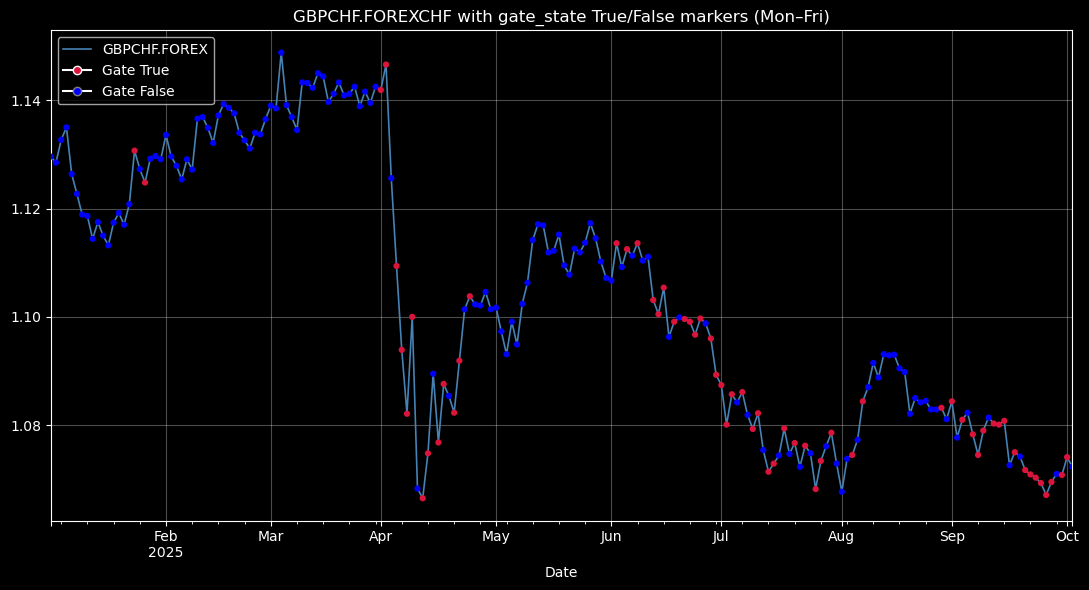

In [27]:

plt.style.use('dark_background')

TAIL_BARS = 1000
# Use Mon–Fri only for plotting to avoid weekend prints often present in FX feeds
# s=s.tail(200)
s_std_plot = functions2.standardize_fx_daily_index(s)

# Select tail for plotting
s_plot = s_std_plot.tail(TAIL_BARS) if TAIL_BARS else s_std_plot
fig, ax = plt.subplots(figsize=(11, 6))
# Base price plot
s_plot.plot(ax=ax, color='steelblue', lw=1.2, label=ticker)
# Align gate_state to price index (gate is Mon–Fri too)
g = gate_stateon.reindex(s_plot.index).fillna(False).astype(bool)
# print(f'gateon aligned to price (last 20 rows):\n{gate_stateon}')
# Overlay markers colored by gate_state state on the price series
colors = np.where(g.values, 'crimson', 'blue')
ax.scatter(s_plot.index, s_plot.values, c=colors, s=12, zorder=3)
# Legend: include price and gate_state state keys
from matplotlib.lines import Line2D
handles, labels = ax.get_legend_handles_labels()
gate_true = Line2D([0],[0], marker='o', color='w', label='Gate True', markerfacecolor='crimson', markersize=6)
gate_false = Line2D([0],[0], marker='o', color='w', label='Gate False', markerfacecolor='blue', markeredgecolor='gray', markersize=6)
ax.legend(handles + [gate_true, gate_false], labels + ['Gate True','Gate False'], loc='upper left')
ax.set_title(f'{ticker}CHF with gate_state True/False markers (Mon–Fri)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [25]:
results = gate_tester.sweep_fxshort_gate(
    price=s,
    gate_fn=fxshort_gates.fxshort_gate,        
    slope_window_vals=(4,5,6,8,10,12,15,16,20),
    consec_vals=(1,2,3),
    slope_entry_thr_vals=(0.0, -1e-4, -3e-4),
    slope_exit_thr_offsets=(0.0, 1e-4, 2e-4),
    consec_rises_kill_vals=(0,1,2,3,4),
    require_carry_vals=(False, True),
    buffer20_vals=(0.002,),
    max_combos=None,
    min_trades=25,
)
top = gate_tester.summarize_top(results, top=1)
print(ticker)
print(top.to_string(index=False))

GBPCHF.FOREX
 carry_ann  slope_window  consec  slope_entry_thr  slope_exit_thr  require_carry  consec_rises_kill  buffer20  trades  win_rate  net_expectancy_per_trade  total_pct_return  avg_pct_return  avg_win  avg_loss  median_holding_days  max_draw_trade_pct  best_trade_pct
      0.04            15       2              0.0             0.0          False                  1     0.002      33  0.636364                  0.001132          0.047881        0.001451 0.005733 -0.006043                  1.0           -0.021566        0.037047
